In [32]:
# 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
%cd /content/drive/MyDrive/AI/인사교_LangChain_20260624

/content/drive/MyDrive/AI/인사교_LangChain_20260624


### 학습내용
- LangGraph 개요
- LangGraph에 자주 등장하는 Python 문법이해
- LangGraph를 활용한 챗봇 구축
- LangGraph를 활용한 Agent 구축
- Agent에 메모리 추가
- 노드의 단계별 스트리밍 출력
- Naive RAG
- 관련성 체커(Relevance Checker) 모듈 추가
- 웹 검색 모듈 추가
- 쿼리 재작성 모듈 추가

### 라이브러리 설치 및 가져오기

In [34]:
# 라이브러리 설치
!pip install -qU langchain langchain-openai langchain-community langchain-experimental
!pip install -qU langchain-chroma faiss-cpu langchain-teddynote
!pip install -qU langchain-tavily google-search-results pypdf
!pip install -qU mypy

In [35]:
# 라이브러리 import
from uuid import uuid4

# 타입 설정
# Sequence : 메시지들의 순서 있는 시퀀스(리스트) 객체 (list 또는 tuple 형태로 메시지를 저장)
# Literal : 값 자체를 타입으로 제한할 수 있도록 해주는 기능
from typing import Annotated, TypedDict, Dict, List, Sequence, Literal
# pydantic : Python 데이터 검증과 설정 관리를 위한 라이브러리
from pydantic import Field, BaseModel, ValidationError

# 상태, 노드
# 노드 : 그래프에서의 작업 단위, 실제 작업을 수행하는 함수
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
# 도구를 노드로 만드는 기능 (자동 맵핑, 상태업데이트, 다중 실행)
from langgraph.prebuilt import ToolNode
# 도구 노드의 결과에 따라 자동으로 라우팅 경로를 설정
from langgraph.prebuilt import tools_condition

# 메모리 저장소
from langgraph.checkpoint.memory import MemorySaver

# 실행 설정
from langchain_core.runnables import RunnableConfig

# 시각화
from IPython.display import Image, display, Markdown
from langchain_teddynote.messages import stream_graph

# 모델 설정
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate, MessagesPlaceholder
# BaseMessage : BaseMessage를 상속한 다양한 메시지 타입 (HumanMessage, AIMessage, SystemMessage)
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage

# 웹 검색 도구
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_tavily import TavilySearch

# 도구 정의 데코레이터
from langchain.tools import tool

# RAG 라이브러리
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings

from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

In [36]:
import os

In [37]:
with open("/content/drive/MyDrive/AI/인사교_LangChain_20260624/key/openai_key.txt", "r") as f:
    api_key = f.read().strip()

os.environ['OPENAI_API_KEY'] = api_key

###LangGraph 개요
- 2024년 1월 출시
- LLM을 사용한 상태유지가 가능한 다중 액터 애플리케이션을 구축하기 위한 라이브러리
  - <font color="red">다중 에이전트 협업</font>: 각기 다른 도메인의 전문 에이전트들이 협력하여 복잡한 문제를 해결
  - <font color="red">도구 정의와 활용</font>: 특정 작업에 적합한 도구들을 정의하고, 이를 에이전트가 활용하는 방법을 설명
  - <font color="red">그래프 기반 시스템 구축</font>: 에이전트들이 서로 통신하고 협력하는 그래프를 생성

#### 기존 workflow의 문제점
- 기존의 sequential한 workflow 기반 RAG는 검색된 데이터의 유사도가 떨어지더라도 참고해서 답변하는 성향이 있다. -> 환각현상이 줄더라도 답변의 신뢰성이 약하다.

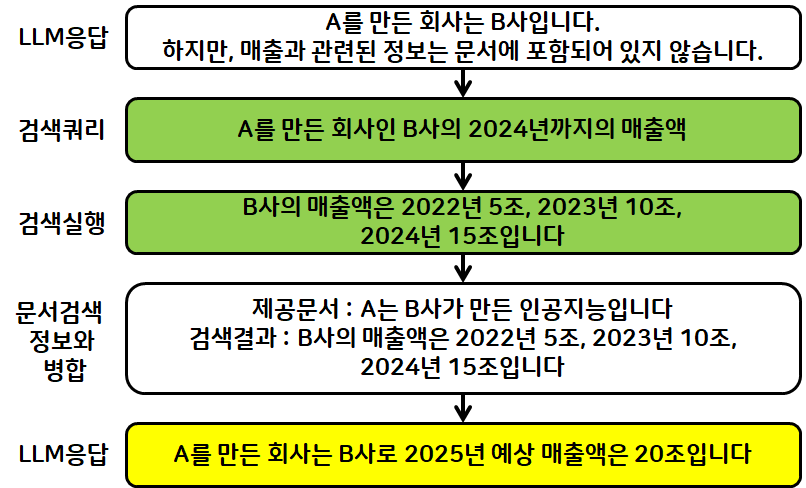

#### 해결방안 : 평가자 추가

- case 1
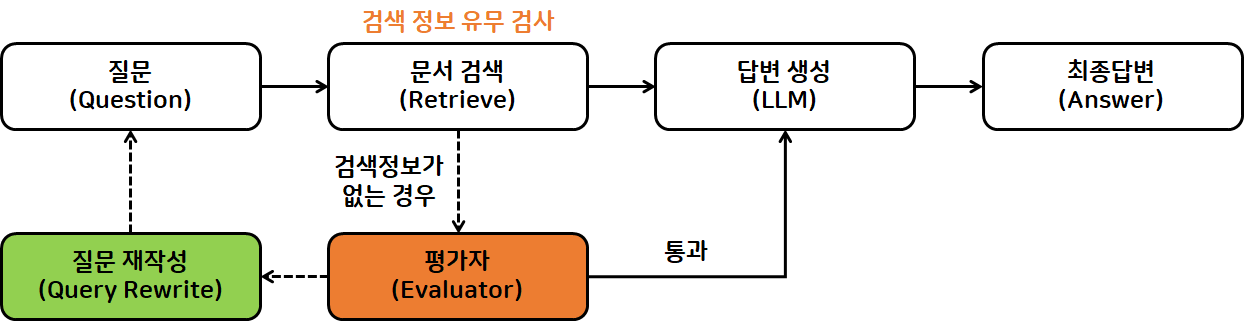

- case 2
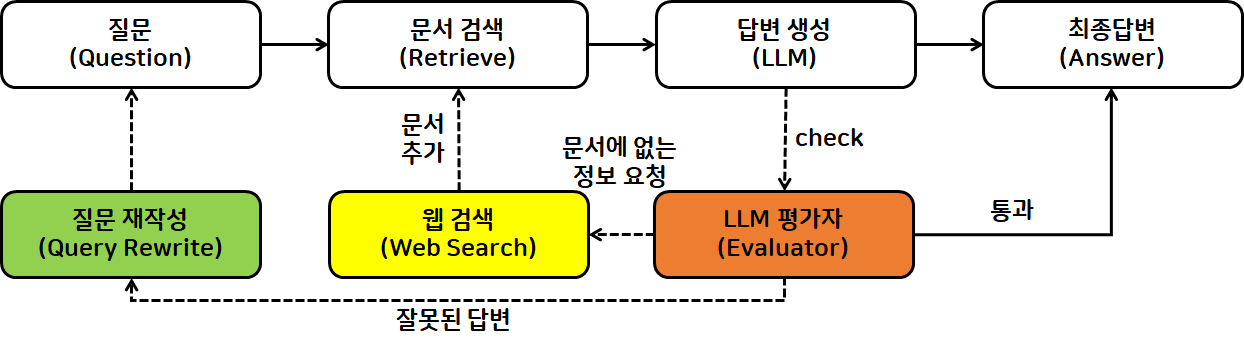

### LangGraph에 자주 등장하는 문법 이해
- LangGraph는 그래프 기반으로 동작하며, 각 노드가 상태(State)를 읽고 수정한 뒤, 수정된 상태를 기반으로 조건 분기를 수행하여 다음 노드를 선택한다.
- LangGraph는 Sequential하게 고정된 순서로 실행되는 것이 아니라, 각 노드가 상태(State)를 읽고 수정하며, 수정된 상태를 바탕으로 조건 분기를 통해 다음에 실행할 노드를 선택하면서 동작한다.

 #### TypedDict
  - dict와의 차이점
    - <font color="red">정적 타입 검사</font> 제공
    - 각 <font color="red">키</font>에 대해 <font color="red">구체적인 타입</font>을 지정해야 함
    - <font color="red">정의된 구조</font>에 따라 사용해야 함 (추가적인 키는 타입 오류 발생)

  - TypedDict를 사용하는 이유
    - 엄격한 타입 검사로 잠재적인 <font color="red">버그 방지</font>
    - 딕셔너리 구조를 명확하게 정의할 수 있어 <font color="red">코드 가독성 향상</font>
    - IDE에서 <font color="red">자동 완성 및 타입 힌트</font>를 더 정확하게 제공
    - 코드 자체가 문서의 역할을 하여 <font color="red">딕셔너리의 구조를 명확히</font> 보여줌     


In [38]:
%%writefile ./source/testDict.py
# 딕셔너리 생성
dict1 = {'name' : '홍길동', 'age':24, 'job':'의적'}

# age를 문자열로 변경
dict1['age'] = '35'

# 새로운 key 추가
dict1['region'] = '장성'

Overwriting ./source/testDict.py


In [39]:
%%writefile ./source/testTypedDict.py
from typing import TypedDict

# 내가 지정한 타입만 들어가는 나만의 dict 생성
class Person(TypedDict):
    name : str
    age : int
    job : str

typed_dict1 : Person = {'name' : '홍길동', 'age':24, 'job':'의적'}

# age를 문자열로 변경
typed_dict1['age'] = '35'

# 새로운 key 추가
typed_dict1['region'] = '장성'

Overwriting ./source/testTypedDict.py


In [40]:
# 실행 후 결과비교
!python3 -m mypy ./source/testDict.py

Success: no issues found in 1 source file


In [41]:
!python3 -m mypy ./source/testTypedDict.py
# 'age' 키는 int 타입이어야 하는데 str 타입의 값이 들어갔다는 경고
# Person TypedDict에 정의되지 않은 'region' 키를 사용하고 있다는 경고

source/testTypedDict.py:12: error: Value of "age" has incompatible type "str"; expected "int"  [typeddict-item]
source/testTypedDict.py:15: error: TypedDict "Person" has no key "region"  [typeddict-unknown-key]
Found 2 errors in 1 file (checked 1 source file)


#### State(상태)
- 노드와 노드 간 정보를 전달할 때 활용
- TypedDict 같은 타입체킹 구조를 활용
- 모든 값을 채우지 않아도 활용 가능
- 새로운 노드에서 값 덮어쓰기 방식으로 활용

In [42]:
# 기본 State 생성
class BasicState(TypedDict):
    context : str
    question : str
    answer : str
    score : str
    relevance : str

#### Node
- 함수로 정의
- 입력인자는 State
- 반환 값도 대부분 State (Conditional Edge의 경우 다를 수 있음)

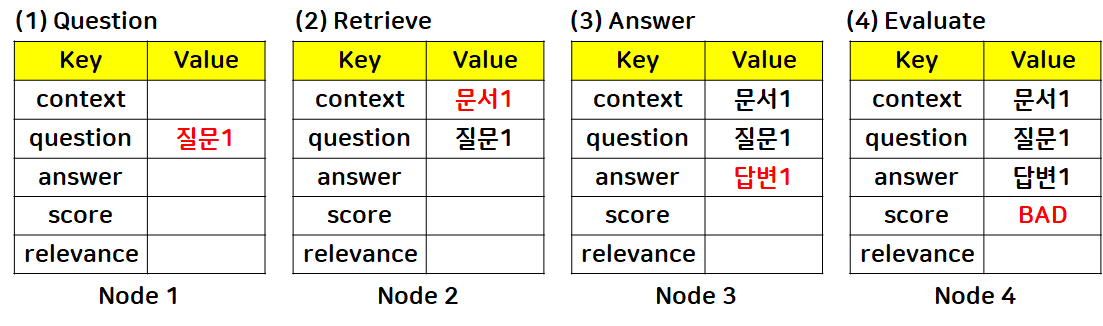

In [43]:
# retrieve_Node 정의
def retrieve_Node(state : BasicState) -> BasicState :
    # 사용자 query에 맞는 chunk를 탐색했다고 가정하고 구성
    state['context'] = '광주는 현재 온도가 24도 입니다. 날씨가 화창하고 좋습니다.'
    return state

# llm_answer_Node 정의
def llm_answer_Node(state : BasicState) -> BasicState :
    # LLM이 답변을 생성했다고 가정하고 구성
    llm_answer = '오늘 광주는 24도입니다. 날씨가 좋으니 산책해보시는 건 어떨까요?'
    return BasicState(answer = llm_answer)

# relevance_check_node 정의
def relevance_check_node(state : BasicState) -> BasicState:
    # retreiver로 검색된 데이터와 LLM이 생성한 답변의 일치도를 검사한다고 가정
    state['relevance'] = 'grounded'     # 검색 문서기반으로 답변이 생성되었다고 표현하는 값 업데이트
    return state

In [44]:
# 노드 등록하기
graph_builder = StateGraph(BasicState)  # 그래프의 베이스 생성
graph_builder.add_node('retrieve_Node', retrieve_Node)    # 노드이름, 수행가능한 노드 함수
graph_builder.add_node('llm_answer_Node', llm_answer_Node)
graph_builder.add_node('relevance_check_node', relevance_check_node)

#### Edge
- 노드와 노드 사이를 연결

In [45]:
graph_builder.add_edge('retrieve_Node', 'llm_answer_Node')       # 시작 노드, 끝 노드
graph_builder.add_edge('llm_answer_Node', 'relevance_check_node')

#### Conditional Edge (조건부 엣지)
- 노드에 조건부 엣지를 추가해 분기를 수행

In [46]:
# router 함수
def is_relevant(state : BasicState) -> Literal['grounded','notGrounded', 'notSure']:
    return state['relevance']

In [47]:
graph_builder.add_conditional_edges(
    source = 'relevance_check_node',            # 조건부 엣지를 붙일 노드이름
    path = is_relevant,                         # 조건분기를 결정하는 함수
    path_map = {                                # 분기될 노드 지정
        'grounded' : END,                       # 문서기반 답변인 경우 끝낸다
        'notGrounded' : 'llm_answer_Node',      # 문서기반 답변이 아니면 LLM으로 보내 재생성
        'notSure' : 'retrieve_Node'             # 모호한 경우 문서검색부터 다시
    }
)

#### 그래프 생성 및 시각화
- 그래프 시작점 지정
- compile
- 시각화

In [48]:
# 시작점 지정
graph_builder.set_entry_point('retrieve_Node')

In [49]:
# 그래프 컴파일
graph = graph_builder.compile()

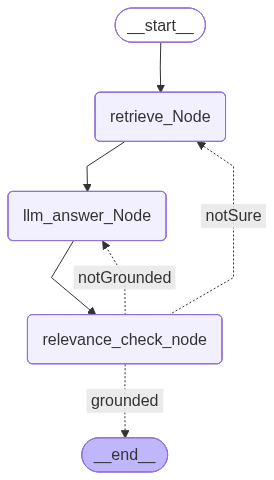

In [50]:
# 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))

### LangGraph 챗봇 구성하기
1. 상태정의
2. 노드정의
3. 그래프 생성 및 노드 추가
4. 엣지 추가 (컨디셔널 엣지 포함)
5. 그래프 컴파일
6. 그래프 시각화
7. 그래프 실행

#### (1) 상태정의

- `messages : Annotated[list, add_messages]`
    - 메시지들은 list 타입을 가짐
    - `add_messages` 함수는 이 상태 키가 어떻게 정의해야 하는지 정의 (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가)

In [51]:
class ChatbotState(TypedDict):
    messages : Annotated[list, add_messages]    # 리스트에 메세지들을 자동으로 추가

#### (2) 노드 정의

In [52]:
# LLM 생성
llm = init_chat_model(model = 'openai:gpt-4o-mini', max_tokens=500)

def chatbot(state : ChatbotState):
    # 메세지 호출 및 반환
    response = llm.invoke(state['messages'])
    return ChatbotState(messages = [response])

#### (3) 그래프 생성 및 노드 추가

In [53]:
chatbot_graph_builder = StateGraph(ChatbotState)

chatbot_graph_builder.add_node('chatbot', chatbot)

#### (4) 엣지 추가

In [54]:
chatbot_graph_builder.set_entry_point('chatbot')
chatbot_graph_builder.add_edge('chatbot', END)

#### (5) 그래프 컴파일

In [55]:
chatbot_graph = chatbot_graph_builder.compile()

#### (6) 그래프 시각화

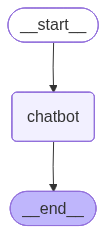

In [56]:
# 그래프 시각화
display(Image(chatbot_graph.get_graph().draw_mermaid_png()))

#### (7) 그래프 실행

In [57]:
question = '광주의 유명한 맛집 Top3 추천해줘'
response = chatbot_graph.invoke({'messages':[('user',question)]})

In [58]:
response

{'messages': [HumanMessage(content='광주의 유명한 맛집 Top3 추천해줘', additional_kwargs={}, response_metadata={}, id='c55f0ef2-700f-4c6a-b3a5-a71e4c71a911'),
  AIMessage(content='광주에서 유명한 맛집 중 Top 3를 추천해드릴게요!\n\n1. **광주떡갈비** - 광주 떡갈비는 지역 특색이 묻어나는 대표적인 요리입니다. 고기가 부드럽고 양념이 잘 배어 있어 맛이 뛰어나며, 떡갈비와 함께 나오는 다양한 반찬들도 인기입니다.\n\n2. **무등산삼겹살** - 광주에서 유명한 삼겹살 전문점으로, 신선한 고기와 다양한 양념이 어우러져 특별한 맛을 제공합니다. 특히, 숯불에 구워내는 삼겹살은 고소하고 풍미가 가득합니다.\n\n3. **충장로 돈까스** - 이곳은 광주에서 인기 있는 돈까스 전문점으로, 두툼한 돈까스와 바삭한 튀김옷이 특징입니다. 밥과 국, 샐러드가 함께 제공되어 푸짐한 한 끼 식사로 제격입니다.\n\n각 맛집마다 고유의 매력이 있으니, 방문해 보시면 좋을 것 같습니다!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 249, 'prompt_tokens': 18, 'total_tokens': 267, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint

### LangGraph를 활용한 Agent 구축

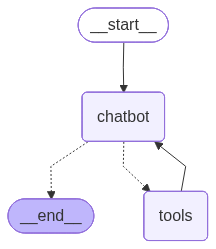

In [59]:
# 웹 검색을 위한 key 등록
with open("/content/drive/MyDrive/AI/인사교_LangChain_20260624/key/tavily_key.txt", "r") as f:
    api_key = f.read().strip()

os.environ['TAVILY_API_KEY'] = api_key

In [60]:
# 상태(state) 정의
class webChatbotState(TypedDict):
    messages : Annotated[list, add_messages]

# 검색 도구 생성
tool_tavily = TavilySearch(max_results=3)

# LLM 모델 생성
llm = init_chat_model(model='gpt-4o-mini', max_tokens=500, temperature=0)

# 도구를 LLM 모델에 바인딩 -> 사용여부를 LLM이 스스로 결정
llm_with_tools = llm.bind_tools([tool_tavily])

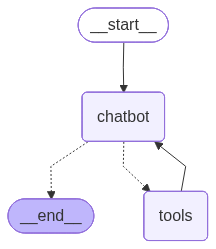

In [61]:
# chatbot 노드 정의
def chatbot(state: webChatbotState) -> webChatbotState:
    response = llm_with_tools.invoke(state['messages'])
    return {'messages' : [response]}    # LLM 응답을 state에 실어서 반환

# LLM 모델 판단에 따라 실행되는 Tool Node 생성
tool_node = ToolNode([tool_tavily])

# 그래프 생성 및 노드 추가
graph_builder = StateGraph(webChatbotState)     # 그래프 베이스 생성
graph_builder.add_node('chatbot', chatbot)      # chatbot 노드 등록
graph_builder.add_node('tools', tool_node)      # Tool Node 등록

# Edge 연결
graph_builder.add_edge(START, 'chatbot')
graph_builder.add_conditional_edges('chatbot', tools_condition)
graph_builder.add_edge('tools', 'chatbot')

# 컴파일 및 시각화
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [62]:
# 그래프 실행
question = '1+1은 뭐야?'
res = graph.invoke({'messages':[('user', question)]})
print(res['messages'][-1].content)
display(res)

1 + 1은 2입니다.


{'messages': [HumanMessage(content='1+1은 뭐야?', additional_kwargs={}, response_metadata={}, id='d73a5937-c149-44af-9cef-b3adc6eb5f7e'),
  AIMessage(content='1 + 1은 2입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 1194, 'total_tokens': 1204, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3be5422b9d', 'id': 'chatcmpl-DyRaBZ1p2KLrE4CCkEbBFO38d6EHE', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f34d9-380d-77d1-ae38-065d8868d5f5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1194, 'output_tokens': 10, 'total_tokens': 1204, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'aud

In [63]:
# 그래프 실행
question = '오늘 광주 날씨 알려줘'
res = graph.invoke({'messages':[('user', question)]})
print(res['messages'][-1].content)
display(res)

오늘 광주의 날씨는 대체로 흐리며, 낮 최고 기온은 30도 이상으로 올라 무더운 날씨가 예상됩니다. 오후에는 소나기가 내릴 가능성이 있으니 우산을 챙기는 것이 좋습니다. 

자세한 정보는 아래 링크에서 확인하실 수 있습니다:
- [광주시청 날씨예보](https://www.gjcity.go.kr/depart/contents.do?mId=0606010000)
- [MSN 날씨 시간별 예측](https://www.msn.com/ko-kr/weather/hourlyforecast/in-%EA%B4%91%EC%A3%BC,%EA%B4%91%EC%A3%BC%EA%B4%91%EC%97%AD%EC%8B%9C)
- [뉴스1 오늘의 날씨](https://www.news1.kr/local/gwangju-jeonnam/6218171)


{'messages': [HumanMessage(content='오늘 광주 날씨 알려줘', additional_kwargs={}, response_metadata={}, id='901e92d6-8287-4d81-8231-2b4ac6fc0498'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 1194, 'total_tokens': 1222, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3be5422b9d', 'id': 'chatcmpl-DyRaCmkHOEPkq3RU7YGwAHKVgVAkG', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f34d9-3d2a-7853-b252-a7930848fe23-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '광주 날씨', 'time_range': 'day', 'topic': 'general'}, 'id': 'call_VQuiAqUjaVAa4yWhqJkwZYxZ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_met

### Agent에 메모리(memory) 추가하기

In [64]:
# chatbot 노드 정의
def chatbot(state: webChatbotState) -> webChatbotState:
    response = llm_with_tools.invoke(state['messages'])
    return {'messages' : [response]}    # LLM 응답을 state에 실어서 반환

# LLM 모델 판단에 따라 실행되는 Tool Node 생성
tool_node = ToolNode([tool_tavily])

# 그래프 생성 및 노드 추가
graph_builder = StateGraph(webChatbotState)     # 그래프 베이스 생성
graph_builder.add_node('chatbot', chatbot)      # chatbot 노드 등록
graph_builder.add_node('tools', tool_node)      # Tool Node 등록

# Edge 연결
graph_builder.add_edge(START, 'chatbot')
graph_builder.add_conditional_edges('chatbot', tools_condition)
graph_builder.add_edge('tools', 'chatbot')

#### MemorySaver 생성
- 프로덕션 단계에서는 SqliteSaver, PostgresSaver 등 활용

In [65]:
memory = MemorySaver()  # 인메모리 세이버

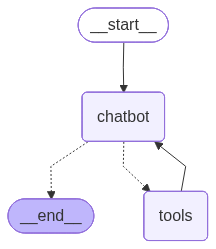

In [66]:
# 컴파일 및 시각화
graph = graph_builder.compile(checkpointer = memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [67]:
# config 설정
config = RunnableConfig(
    configurable = {'thread_id' : '001'}
)

In [68]:
# 그래프 실행
question = '안녕 내 이름은 누구야'
res = graph.invoke({'messages':[('user', question)]}, config=config)
print(res['messages'][-1].content)
display(res)

안녕하세요! 당신의 이름을 알 수 없지만, 어떻게 도와드릴까요?


{'messages': [HumanMessage(content='안녕 내 이름은 누구야', additional_kwargs={}, response_metadata={}, id='f3d3d5c3-7e40-4aba-b35c-efc17371a83a'),
  AIMessage(content='안녕하세요! 당신의 이름을 알 수 없지만, 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1194, 'total_tokens': 1214, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3be5422b9d', 'id': 'chatcmpl-DyRaR8axYtmrH7y6j5iiCXfzED2ur', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f34d9-7904-7be0-bcd1-ace18bebac49-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1194, 'output_tokens': 20, 'total_tokens': 1214, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'o

In [69]:
# 그래프 실행
question = '내 이름이 누구라니까?'
res = graph.invoke({'messages':[('user', question)]}, config=config)
print(res['messages'][-1].content)
display(res)

"누구"라는 이름이군요! 반갑습니다, 누구님! 어떻게 도와드릴까요?


{'messages': [HumanMessage(content='안녕 내 이름은 누구야', additional_kwargs={}, response_metadata={}, id='f3d3d5c3-7e40-4aba-b35c-efc17371a83a'),
  AIMessage(content='안녕하세요! 당신의 이름을 알 수 없지만, 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1194, 'total_tokens': 1214, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3be5422b9d', 'id': 'chatcmpl-DyRaR8axYtmrH7y6j5iiCXfzED2ur', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f34d9-7904-7be0-bcd1-ace18bebac49-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1194, 'output_tokens': 20, 'total_tokens': 1214, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'o

In [70]:
# 그래프 실행
question = '내 이름이 뭐라고?'
res = graph.invoke({'messages':[('user', question)]}, config=config)
print(res['messages'][-1].content)
display(res)

당신의 이름은 "누구"입니다!


{'messages': [HumanMessage(content='안녕 내 이름은 누구야', additional_kwargs={}, response_metadata={}, id='f3d3d5c3-7e40-4aba-b35c-efc17371a83a'),
  AIMessage(content='안녕하세요! 당신의 이름을 알 수 없지만, 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1194, 'total_tokens': 1214, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3be5422b9d', 'id': 'chatcmpl-DyRaR8axYtmrH7y6j5iiCXfzED2ur', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f34d9-7904-7be0-bcd1-ace18bebac49-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1194, 'output_tokens': 20, 'total_tokens': 1214, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'o

In [71]:
# 그래프 실행
question = '내가 좋아하는 요리 추천해줘'
res = graph.invoke({'messages':[('user', question)]}, config=config)
print(res['messages'][-1].content)
display(res)

좋아하는 요리에 대한 정보가 없어서, 일반적으로 인기 있는 요리 몇 가지를 추천해드릴게요:

1. **파스타** - 다양한 소스와 재료로 만들 수 있어요.
2. **피자** - 원하는 토핑으로 개인화할 수 있는 요리입니다.
3. **초밥** - 신선한 재료로 만든 일본 요리입니다.
4. **타코** - 다양한 재료를 넣어 즐길 수 있는 멕시코 요리입니다.
5. **볶음밥** - 남은 재료로 간편하게 만들 수 있는 요리입니다.

어떤 요리를 좋아하시나요? 더 구체적인 추천이 필요하시면 말씀해 주세요!


{'messages': [HumanMessage(content='안녕 내 이름은 누구야', additional_kwargs={}, response_metadata={}, id='f3d3d5c3-7e40-4aba-b35c-efc17371a83a'),
  AIMessage(content='안녕하세요! 당신의 이름을 알 수 없지만, 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1194, 'total_tokens': 1214, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3be5422b9d', 'id': 'chatcmpl-DyRaR8axYtmrH7y6j5iiCXfzED2ur', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f34d9-7904-7be0-bcd1-ace18bebac49-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1194, 'output_tokens': 20, 'total_tokens': 1214, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'o

In [72]:
# 스냅샷 생성하기
snapshot = graph.get_state(config)
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='안녕 내 이름은 누구야', additional_kwargs={}, response_metadata={}, id='f3d3d5c3-7e40-4aba-b35c-efc17371a83a'), AIMessage(content='안녕하세요! 당신의 이름을 알 수 없지만, 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1194, 'total_tokens': 1214, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3be5422b9d', 'id': 'chatcmpl-DyRaR8axYtmrH7y6j5iiCXfzED2ur', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f34d9-7904-7be0-bcd1-ace18bebac49-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1194, 'output_tokens': 20, 'total_tokens': 1214, 'input_token_details': {'audio': 0, '

### Stream 모드 사용하기
- https://serpapi.com/search-api

In [73]:
# 웹 검색을 위한 key 등록
with open('/content/drive/MyDrive/AI/인사교_LangChain_20260624/key/serp_api_key.txt', 'r') as f:
    api_key = f.read().strip()

os.environ['SERPAPI_API_KEY'] = api_key

In [74]:
from langchain_community.utilities import SerpAPIWrapper

In [75]:
# 상태(state) 정의
class webChatbotState(TypedDict):
    messages : Annotated[list, add_messages]
    # 테스트를 위한 더미 변수
    dummy_data : Annotated[str, 'dummy']

# tool 정의
@tool
def search_keyword(query:str) -> List[Dict[str, str]]:
    '''키워드로 구글 뉴스 검색'''
    search = SerpAPIWrapper()
    return search.run(query)

# LLM 모델 생성
llm = init_chat_model(model='gpt-4o-mini', max_tokens=500, temperature=0)

# 도구를 LLM 모델에 바인딩 -> 사용여부를 LLM이 스스로 결정
llm_with_tools = llm.bind_tools([search_keyword])

In [76]:
# chatbot 노드 정의
def chatbot(state: webChatbotState) -> webChatbotState:
    response = llm_with_tools.invoke(state['messages'])
    return {'messages' : [response]}    # LLM 응답을 state에 실어서 반환

# LLM 모델 판단에 따라 실행되는 Tool Node 생성
tool_node = ToolNode([search_keyword])

# 그래프 생성 및 노드 추가
graph_builder = StateGraph(webChatbotState)     # 그래프 베이스 생성
graph_builder.add_node('chatbot', chatbot)      # chatbot 노드 등록
graph_builder.add_node('tools', tool_node)      # Tool Node 등록

# Edge 연결
graph_builder.add_edge(START, 'chatbot')
graph_builder.add_conditional_edges('chatbot', tools_condition)
graph_builder.add_edge('tools', 'chatbot')

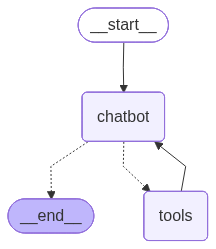

In [77]:
memory = MemorySaver()  # 인메모리 세이버

# 컴파일 및 시각화
graph = graph_builder.compile(checkpointer = memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [78]:
# config 설정
config = RunnableConfig(
    configurable = {'thread_id' : '002'},   # 메모리 구분 id
    recursion_limit = 20    # 그래프 실행 중에 노드를 수행하는 횟수 최대치
)

In [79]:
# 질문
question = '2026년 AI 관련 기술 동향 뉴스를 알려줘.'

# 입력으로 넣을 초기 상태값 정의
input = webChatbotState(messages=[('user', question)],
                        dummy_data = '테스트 문자열')

# 각 노드들의 실행 결과를 반환
for res in graph.stream(input=input, config=config):
    for value in res.values():
        value['messages'][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  search_keyword (call_Xexr11umPGw51l6RTqlVIaNF)
 Call ID: call_Xexr11umPGw51l6RTqlVIaNF
  Args:
    query: 2026 AI technology trends
================================= Tool Message =================================
Name: search_keyword

['Seven AI trends to watch in 2026 will make AI a true partner — boosting teamwork, security, research momentum and infrastructure efficiency.', 'Five AI trends will shape IT in 2026 · 1. Foundational AI principles will rewrite organizational DNA · 2. From copilots to vibe coding: AI will continue to ...', 'Reporter Anabelle Nicoud spoke to several experts across AI, security, quantum and beyond to better understand where tech will take us in 2026.', "From the AI bubble to GenAI's rise as an organizational tool, these are the 2026 AI trends to watch. Explore new data and advice from AI experts ...", '2026 is going to be the year where organizations finally feel 

In [80]:
# 질문
question = '2026년 AI 동향 알려줘'

# 입력으로 넣을 초기 상태값 정의
input = webChatbotState(messages=[('user', question)],
                        dummy_data = '테스트 문자열')

# 각 노드들의 실행 결과를 반환
# stream_mode
# - updates(기본값) : 노드에서 업데이트한 속성 값 출력
# - values : 노드에서 출력되는 state를 그대로 출력
for res in graph.stream(input=input, config=config, stream_mode='updates'):
    print(res)
    print()
    # for value in res.values():
        # value['messages'][-1].pretty_print()

{'chatbot': {'messages': [AIMessage(content="2026년 AI 동향에 대한 주요 내용은 다음과 같습니다:\n\n1. **AI의 파트너십 강화**: AI는 팀워크와 협업을 증진시키는 진정한 파트너로 자리 잡을 것입니다. 이는 보안, 연구, 인프라 효율성 등 다양한 분야에서의 협력을 포함합니다.\n\n2. **조직의 DNA 재편성**: AI의 기본 원칙들이 조직의 운영 방식에 큰 변화를 가져오며, AI는 다양한 형태로 발전할 것입니다. 예를 들어, 코파일럿 기능이나 새로운 프로그래밍 방식인 '바이브 코딩' 등이 포함됩니다.\n\n3. **혁신의 해**: 2026년에는 기업들이 AI를 활용하여 혁신적인 접근 방식을 시도하고, 새로운 아이디어를 실험하는 데 더 많은 자신감을 가질 것으로 예상됩니다.\n\n4. **AI 기반 하이퍼 스프린트**: 제품 개발 주기가 급격히 단축되어, 과거에는 몇 주가 걸리던 작업이 이제는 반나절 만에 완료될 수 있는 혁신이 이루어질 것입니다.\n\n5. **신뢰성과 보안의 중요성**: AI 시스템의 신뢰성과 보안이 중요한 초점이 될 것이며, 이는 시스템이 오류에서 회복하고 예측 가능한 행동을 유지하는 것을 포함합니다.\n\n이러한 동향들은 AI 기술이 앞으로 어떻게 발전하고, 조직에 통합될지를 보여줍니다.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 316, 'prompt_tokens': 600, 'total_tokens': 916, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_token

In [81]:
# 질문
question = '2026년 AI 동향 알려줘'

# 입력으로 넣을 초기 상태값 정의
input = webChatbotState(messages=[('user', question)],
                        dummy_data = '테스트 문자열')

# 각 노드들의 실행 결과를 반환
for res in graph.stream(input=input, config=config, stream_mode='values'):
    print(res)
    print()
    # for value in res.values():
        # value['messages'][-1].pretty_print()

{'messages': [HumanMessage(content='2026년 AI 관련 기술 동향 뉴스를 알려줘.', additional_kwargs={}, response_metadata={}, id='560d8e5a-0986-4fd8-9044-a55c86330c1f'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 59, 'total_tokens': 77, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_def81a1071', 'id': 'chatcmpl-DyRanlaH1c44XXVBLJK3U5xcRT6gH', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f34d9-cc43-72c2-97ff-4e221c821d8f-0', tool_calls=[{'name': 'search_keyword', 'args': {'query': '2026 AI technology trends'}, 'id': 'call_Xexr11umPGw51l6RTqlVIaNF', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_t

# Naive RAG
- RAG의 가장 기본적인 형태
- 복잡한 후처리나 정교한 쿼리 최적화 없이 단순하게 "문서 검색 → 응답 생성"의 구조만을 갖춘 기본형 RAG 파이프라인
- 구성요소
  - 질문 (Query) 입력
  - 문서 검색기 (Retriever) → 벡터 DB (예: FAISS, Chroma) 등에서 관련 문서 K개 검색
  - LLM에 프롬프트 입력 (Prompt) → 검색된 문서를 함께 넣어 질문에 답하게 함
  - LLM 응답 생성

<center>  
<img src="https://arome1004.cafe24.com/images/langchain/langgraph26.png" width=15%>   
</center>  

#상태정의

In [82]:
class RAGState(TypedDict) :
  question: Annotated[str, "User Question"] # 사용자 질문
  context: Annotated[str, "Context"] # 관련문서 검색 결과
  answer: Annotated[str, "Answer"] # 답변
  messages: Annotated[list, add_messages] # 메세지(list로 누적)

- 문서로드/Chunking/임베딩/벡터DB저장/검색기 설정

In [83]:
# 문서 로드
loader = PyPDFLoader("/content/drive/MyDrive/AI/인사교_LangChain_20260624/data/SPRi AI Brief_11월호산업동향.pdf")
documents = loader.load()

documents

[Document(metadata={'producer': 'Hancom PDF 1.3.0.547', 'creator': 'Hwp 2018 10.0.0.13947', 'creationdate': '2024-11-05T15:04:26+09:00', 'author': 'dj', 'moddate': '2024-11-05T15:04:26+09:00', 'pdfversion': '1.4', 'source': '/content/drive/MyDrive/AI/인사교_LangChain_20260624/data/SPRi AI Brief_11월호산업동향.pdf', 'total_pages': 25, 'page': 0, 'page_label': '1'}, page_content='2024년 11월호'),
 Document(metadata={'producer': 'Hancom PDF 1.3.0.547', 'creator': 'Hwp 2018 10.0.0.13947', 'creationdate': '2024-11-05T15:04:26+09:00', 'author': 'dj', 'moddate': '2024-11-05T15:04:26+09:00', 'pdfversion': '1.4', 'source': '/content/drive/MyDrive/AI/인사교_LangChain_20260624/data/SPRi AI Brief_11월호산업동향.pdf', 'total_pages': 25, 'page': 1, 'page_label': '2'}, page_content='2024년 11월호\nⅠ. 인공지능 산업 동향 브리프 1. 정책/법제    ▹ 미국 민권위원회, 연방정부의 얼굴인식 기술 사용에 따른 민권 영향 분석························1   ▹ 미국 백악관 예산관리국, 정부의 책임 있는 AI 조달을 위한 지침 발표·····························2   ▹ 유로폴, 법 집행에서 AI의 이점과 과제를 다

In [84]:
# Chunking
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500, # 청크의 크기
    chunk_overlap = 50, # 청크끼리 겹쳐지는 글자 수
)
texts = text_splitter.split_documents(documents)
for t in texts :
  print(len(t.page_content))


10
10
497
491
496
290
393
17
277
496
495
334
256
497
497
375
267
496
499
345
228
498
496
368
270
498
497
360
273
497
492
282
259
498
498
116
134
258
499
498
475
260
495
498
67
116
229
499
498
54
132
266
498
499
248
244
498
494
495
95
266
495
499
379
223
498
496
120
277
273
499
495
190
277
497
498
402
252
494
497
242
284
497
492
273
247
496
496
292
268
498
496
492
74
487
241
227


In [85]:
# 임베딩/벡터DB저장
vec_db = FAISS.from_documents(texts, OpenAIEmbeddings())

In [86]:
# 검색기 설정
retriver = vec_db.as_retriever(search_kwargs={"k": 2})

- 노드 정의

In [87]:
# LLM 초기화
llm = init_chat_model(model="gpt-4o-mini", max_tokens=500, temperature=0)

# 문서 검색 노트
def retrieve_node(s : RAGState) -> RAGState :
  # 사용자 질문기반 검색
  docs = retriver.invoke(s['question'])
  # 검색된 Document 객체들을 하나의 문자열로 병합
  context_str = "\n\n".join([ d.page_content for d in docs])

  return {"context" : context_str}

#답변 생성 노드
def llm_answer(s : RAGState) -> RAGState :
  # 프롬프트 설정
  system_prompt = """
  당신은 유능한 어시스턴트입니다. 아래 검색된 내용을 바탕으로 답변하세요.
  답변 시 출처(Source) 정보도 포함해 주세요.

  {context}
  """
# 템플릿 생성
  template = ChatPromptTemplate.from_messages([
      ('system', system_prompt),
      MessagesPlaceholder(variable_name="chat_history"),
      ('human', "{input}")
  ])
  # 체인 연결하기
  chain = template | llm | StrOutputParser()

  # 체인 호출
  response = chain.invoke(
      {
          "context" : s['context'],
          "chat_history" : s.get("messages", []),
          "input" : s['question']
      }

  )
  # 생성된 답변 반환
  return RAGState(
      answer = response,
      messages = [
          ('user',s['question']),
          ('ai', response)
      ]
  )

# 그래프 생성 및 실행 (실습)
1. 그래프 생성
2. 노드 추가
3. 엣지 추가
4. 메모리(체크포인트) 생성
5. 그래프 컴파일 및 시각화
6. 그래프 실행

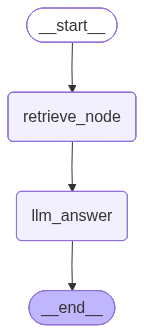

In [88]:
# 그래프 생성
workflow = StateGraph(RAGState)
# 노드 추가
workflow.add_node("retrieve_node", retrieve_node)
workflow.add_node("llm_answer", llm_answer)
# 엣지 추가
workflow.add_edge(START, "retrieve_node")
workflow.add_edge("retrieve_node", "llm_answer")
workflow.add_edge("llm_answer", END)
# 체크포인트 생성
memory = MemorySaver()
# 컴파일
app = workflow.compile(checkpointer=memory)
# 시각화
display(Image(app.get_graph().draw_mermaid_png()))

In [89]:
# 설정 값
config = RunnableConfig(
    configurable={'thread_id' : 'rag_test_01'}
)
# 질문
query = "생성형 AI가 인간 근로자를 대체할 가능성에 대해서 어떻게 생각하니?"

# 그래프 실행
# invoke -> 최종 결과를 확인하는 경우
# stream -> 중간중간 노드 실행결과를 확인하는 경우
output = app.invoke(input = RAGState(question=query), config=config)

In [90]:
output['answer']

'생성형 AI가 인간 근로자를 대체할 가능성은 현재로서는 매우 낮다고 평가되고 있습니다. 미국의 채용 플랫폼 인디드(Indeed) 산하 연구소 하이어링랩(Hiring Lab)의 연구에 따르면, 2,800개 이상의 직무 기술을 분석한 결과, 생성 AI가 인간을 대체할 가능성이 "매우 낮음" 또는 "낮음"으로 평가된 직무가 68.7%에 달했습니다. 특히, 생성 AI는 기술과 관련된 이론적 지식을 제공하는 데 강점을 보이지만, 물리적 작업 수행이 필요한 직무에서는 대체 가능성이 희박하다고 합니다. \n\n결론적으로, 생성형 AI는 특정 분야에서 유용한 도구가 될 수 있지만, 인간 근로자를 완전히 대체하기에는 한계가 있는 것으로 보입니다. (출처: 인디드 하이어링랩, 2024년 9월 25일 발표)'

# 관련성 체커 (Relevance Check) 모듈 추가
- Naive RAG 수행
- **검색된 문서에 대한 관련성 체크**

<center>  
<img src="https://arome1004.cafe24.com/images/langchain/langgraph27.png" width=20%>   
</center>   

- 관련성 결과를 저장하는 상태 속성 추가

In [91]:
class RAGState(TypedDict) :
  question: Annotated[str, "User Question"] # 사용자 질문
  context: Annotated[str, "Context"] # 관련문서 검색 결과
  answer: Annotated[str, "Answer"] # 답변
  messages: Annotated[list, add_messages] # 메세지(list로 누적)
  relevance: Annotated[str, "Relevance"] # 관련성 체크결과 (yes or no)

- 관련성 체크 노드 추가

In [92]:
# 출력 구조 정의 -> Pydantic을 사용해서 yes or no 강제
class RelevanceScore(BaseModel) :
  score : str = Field(description="사용자 질문과 문서와 관련 있으면 'yes'm 없으면 'no'")

# 관련성 체크 노드 구현
def relevance_check(s : RAGState) -> RAGState :
  # 구조화된 출력으로 설정한 LLM
  structured_llm = llm.with_structured_output(RelevanceScore)

  # 평가 프롬프트
  system_prompt = '''
    당신은 검색된 문서와 사용자 질문간의 관련성을 평가하는 역할입니다.
    검색된 문서(context)가 사용자 질문(question)에 대답하는 데 도움이 되는 정보를
    포함하고 있는지 확인해주세요.

    - 조금이라도 관련이 있다면 'yes'
    - 전혀 관련이 없는 내용이라면 'no'
    - 오직 'yes' 또는 'no'로 대답해주세요.
    '''
  template = ChatPromptTemplate.from_messages([
      ('system', system_prompt),
      ('human', "Context : {context} \n\n Question : {question}")
  ])
  # 체인 구성 및 실행
  checker_chain = template | structured_llm

  response = checker_chain.invoke({
      "context" : s['context'],
      "question" : s['question']
  })
  # 확인용 출력
  print(f"=========[RELEVANCE CHECK] : {response.score}")
  # 상태업데이트 리턴
  return RAGState(relevance=response.score)

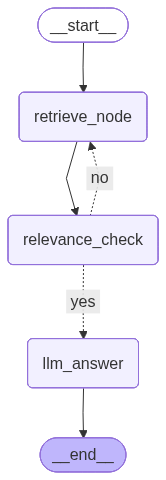

In [93]:
# 그래프 생성
workflow = StateGraph(RAGState)
# 노드 추가
workflow.add_node("retrieve_node", retrieve_node)
workflow.add_node("relevance_check", relevance_check) # 관련성 검사노드 추가
workflow.add_node("llm_answer", llm_answer)
# 엣지 추가
workflow.add_edge(START, "retrieve_node")
workflow.add_edge("retrieve_node", "relevance_check")
# 조건부 엣지 추가
### 라우터 함수
def is_relevant(s:RAGState) -> RAGState :
  return s['relevance']
workflow.add_conditional_edges(
    "relevance_check", # 조건분기 시작노드
    is_relevant, # 라우터 함수 추가
    {
        "yes" : "llm_answer",
        "no" : "retrieve_node"
    }
)
workflow.add_edge("llm_answer", END)
# 체크포인트 생성
memory = MemorySaver()
# 컴파일
app = workflow.compile(checkpointer = memory)
# 시각화
display(Image(app.get_graph().draw_mermaid_png()))

- 그래프 실행

In [94]:
from langgraph.errors import GraphRecursionError

In [95]:
config = RunnableConfig(
    configurable={'thread_id' : 'rag_test_02'},
    recursion_limit = 20, # 최대 재귀횟수 설정
)
query = "2026년 AI 트렌드 알려줘"
input = RAGState(question=query)
# 예외처리
try :
  output = app.invoke(input=input, config=config)
except GraphRecursionError as e:
  print("재귀 횟수 초과")
  print(e)

=========[RELEVANCE CHECK] : no
=========[RELEVANCE CHECK] : no
=========[RELEVANCE CHECK] : no
=========[RELEVANCE CHECK] : no
=========[RELEVANCE CHECK] : no
=========[RELEVANCE CHECK] : no
=========[RELEVANCE CHECK] : no
=========[RELEVANCE CHECK] : no
=========[RELEVANCE CHECK] : no
=========[RELEVANCE CHECK] : no
재귀 횟수 초과
Recursion limit of 20 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT


In [96]:
config = RunnableConfig(
    configurable={'thread_id' : 'rag_test_03'},
    recursion_limit = 20, # 최대 재귀횟수 설정
)
query = "생성형 AI가 인간 근로자를 대체할 가능성에 대해서 어떻게 생각하니?"
input = RAGState(question=query)
output = app.invoke(input=input, config=config)


=========[RELEVANCE CHECK] : yes


# 웹 검색 모듈 추가
- Naive RAG 수행
- 검색된 문서에 대한 관련성 체크
- **Web Search 추가**

<center>  
<img src="https://arome1004.cafe24.com/images/langchain/langgraph28.png" width=30%>   
</center>  

- Web Search 노드 정의

In [170]:
# 도구생성
tavily_tool = TavilySearch(max_results=3)

def web_search(s : RAGState) -> RAGState :
  # 검색결과 반환
  search_result = tavily_tool.invoke(s['question'])

  #검색결과를 하나로 병합
  context = "\n\n".join([
     doc['content'] for doc in search_result['results']
  ])

  return RAGState(context=context)

- 그래프 구성하기

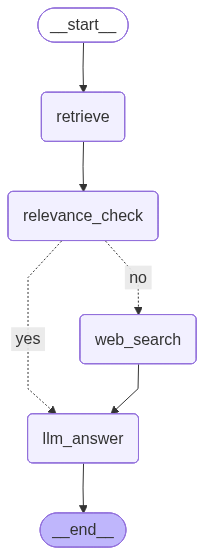

In [134]:
# 그래프 정의
workflow = StateGraph(RAGState)

# 노드 정의
workflow.add_node("retrieve", retrieve_node)
workflow.add_node("relevance_check", relevance_check)
workflow.add_node("web_search", web_search)
workflow.add_node("llm_answer", llm_answer)

# 엣지 정의
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "relevance_check")
## 조건부 엣지 추가
def is_relevant(s:RAGState) -> RAGState :
  return s['relevance']
workflow.add_conditional_edges(
    "relevance_check", # 조건 분기가 시작될 노드이름
    is_relevant, # 라우터 함수
    { # path map
        "yes" : "llm_answer",
        "no" : "web_search"
        }
)
workflow.add_edge("web_search","llm_answer")
workflow.add_edge("llm_answer", END)

# 체크포인터 생성(메모리 역할)
memory = MemorySaver()
# 그래프 컴파일
app = workflow.compile(checkpointer=memory)
# 그래프 시각화
display(Image(app.get_graph().draw_mermaid_png()))

- 실행

In [135]:
# config
config = RunnableConfig(
    configurable={'thread_id' : 'rag_test_04'},
    recursion_limit = 10, # 그래프에서 실행되는 노드의 최대 횟수
)

In [131]:
# 관련성 질문
query = "생성형 AI가 인간 근로자를 대체할 가능성에 대해 어떻게 생각하나요?"
input = RAGState(question=query)

# 그래프 실행
for result in app.stream(input=input, config=config) :
  print(result)

{'retrieve': {'context': '£생성AI, 문제 해결 역량 및 물리적 작업 수행 역량의 부족으로 인간 근로자 대체에 한계n미국의 채용 플랫폼 인디드(Indeed) 산하 연구소 하이어링랩(Hiring Lab)이 2024년 9월 25일 발표한 연구 결과에 따르면 생성AI가 인간 근로자를 대체할 가능성은 희박∙인디드 하이어링랩은 오픈AI의 GPT-4o로 2,800개 이상의 고유한 직무 기술에 대한 생성AI의 수행 능력을 분석해 생성AI가 인간을 대체할 가능성을 평가∙연구진은 오픈AI의 GPT-4o가 △기술과 관련된 이론적 지식의 제공 역량 △기술을 사용한 문제 해결 역량 △기술 활용 시 물리적 작업의 중요성에 관한 판단 능력의 3개 차원에서 자체 수행 능력을 평가하도록 진행 ∙다섯 가지 선택지(매우 낮음, 낮음, 보통, 높음, 매우 높음)로 평가 결과, 인디드가 평가 대상으로 삼은 2,800개 이상의 직무 기술 중 68.7%는 생성AI로 대체될 가능성이 “매우 낮음” 또는 “낮음”으로 평가됐으며, “매우 높음”으로\n\nSPRi AI Brief |  2024-11월호\n20\n인디드 조사 결과, 생성AI가 인간 근로자 대체할 가능성은 희박n인디드가 2,800개 이상의 직무 기술에 대한 생성AI의 수행 능력을 분석해 인간을 대체할 가능성을 평가한 결과, 생성AI로 대체될 가능성이 “매우 높은” 것으로 평가된 기술은 전무n생성AI의 최대 강점은 직무 기술과 관련된 이론적 지식을 제공하는 능력이며, 물리적 작업 수행이 필요한 직무 기술에서는 인간 근로자를 대체할 가능성이 희박 \nKEY Contents'}}
=========[RELEVANCE CHECK] : yes
{'relevance_check': {'relevance': 'yes'}}
{'llm_answer': {'answer': '생성형 AI가 인간 근로자를 대체할 가능성에 대한 최근 연구 결과에 따르면, 그 가능성은 매우 낮은 것으로 평가되고 있습니다. 미국의 채용 플랫폼 인디드(Indeed) 산

In [ ]:
tavily_tool.invoke("양자컴퓨터")

In [138]:
# 관련성이 없는 질문
query = "한국 역사 알려줘"
input = RAGState(question=query)

# 그래프 실행
for result in app.stream(input=input, config=config) :
  print(result)

{'retrieve': {'context': '경기도 성남시 분당구 대왕판교로 712번길 22 글로벌 R&D 연구동(B) 4층22, Daewangpangyo-ro 712beon-gil, Bundang-gu, Seongnam-si, Gyeonggi-do, Republic of Korea, 13488\n홈페이지 : https://spri.kr/보고서와 관련된 문의는 AI정책연구실(hs.lee@spri.kr, 031-739-7333)로 연락주시기 바랍니다.\n\n2024년 11월호'}}
=========[RELEVANCE CHECK] : no
{'relevance_check': {'relevance': 'no'}}
{'web_search': {'context': '# 한국의 역사. | 선사 시대  * 구석기 시대 * 신석기 시대 (빗살무늬토기 시대) * 청동기 시대 (민무늬토기 시대) |. ~ 기원전 194년   + 위만조선 기원전 194년 ~ 기원전 108년 * 진국 기원전 3세기 ~ 기원전 2세기 * 부여 기원전 4세기 ~ 서기 494년 |. | 원삼국 시대  * 철기 시대 * 옥저 * 동예 * 삼한 (마한 · 진한 · 변한) |. | 삼국 시대  * 신라 기원전 57년 ~ 935년 * 고구려 기원전 37년 ~ 668년 * 백제 기원전 18년 ~ 660년 * 가야 42년 ~ 562년 * 탐라 ? | 고려 시대  * 고려 918년 ~ 1392년 |. | 조선 시대  * 조선 1392년 ~ 1897년 |. **한국의 역사** 또는 **한국사**(韓國史)는 선사 시대부터 현대까지 동아시아의 한반도, 만주, 연해주 지역을 바탕으로 전개된 한국의 역사이다. 한국사의 시대 구분은 구석기 시대에서부터 신석기 시대, 청동기 시대, 철기 시대로 구분되는 선사시대와 고조선의 성립 이후 원삼국 시대, 삼국 시대, 남북국 시대, 후삼국 시대까지의 고대, 고려 시대인 중세, 조선 시대인 근세, 대한제국 수립 이후 오늘날까지의 근·현대 등으로 구분된다. 이 부분의 본문은 한국의 구석기 

 # 쿼리 재작성 모듈 추가
- Naive RAG 수행
- 검색된 문서에 대한 관련성 체크
- Web Search
- **Query Rewrite**


<center>  
<img src="https://arome1004.cafe24.com/images/langchain/langgraph29.png" width=30%>   
</center>  

- Query rewrite 노드 추가

In [141]:
rewrite_prompt = ChatPromptTemplate.from_template("""
벡터 스토어 검색의 효율성을 높이기 위해 주어진 질문을 재공식화한다.

- 초기 질문을 분석하여 특이성, 명확성, 관련성 등 개선이 필요한 영역을 식별한다.
- 검색을 최적화할 수 있는 컨텍스트 및 잠재적 키워드를 고려한다.
- 원래 질문의 의도를 유지하면서 구조와 어휘를 강화한다.

# 처리 프로세스

1. **원래 질문 이해**: 핵심 의도와 키워드를 식별한다.
2. **명확성 향상**: 언어를 단순화하고 질문이 직접적이고 요점이 명확하도록 한다.
3. **검색 최적화**: 벡터스토어 인덱싱과 더 잘 일치하도록 키워드를 추가하거나 재배열한다.
4. **검토**: 개선된 질문이 원래 의도를 정확하게 반영하고 모호함이 없는지 확인한다.

# 출력 형식

- 개선된 단일 질문을 제공한다.
- 소개나 설명 텍스트를 포함하지 마세요. 단지 재구성된 질문일 뿐이다.

# 예시

**입력**:
"화석 연료에 비해 재생 가능 에너지원의 이점은 ?"

**출력**:
"재생 가능 에너지원은 이점 측면에서 화석 연료와 어떤 장점/단점/특징을 가지고 있습니까?"

**입력**:
"기후 변화와 북극곰 개체수 ?"

**출력**:
"어떤 기후 변화가 북극곰 개체수에 어떤 영향을 미치나요?"

# 메모

- 개선된 질문이 간결하고 상황에 맞는지 확인하세요.
- 원래 질문의 근본적인 의도나 의미를 변경하지 마십시오.

[주의점] 다시 작성된 질문은 원래 질문과 동일한 언어로 작성되어야 합니다.

# 다시 작성해야 할 원래 질문은 다음과 같다.:
{question}
""")

# 체인구성
question_rewriter = rewrite_prompt | llm | StrOutputParser()


In [142]:
# 체인호출
question_rewriter.invoke({"question" : "AI 타분야 적용 사례"})

'"AI는 어떤 타 분야에서 어떻게 적용되고 있습니까?"'

#실습
- 1. 사용자 질문을 재작성하여 state에 업데이트하는 Query rewrite 노드 추가
- 2. (optional)Web search로 나온 문서청크의 적합성을 검사하는 루틴 추가

In [164]:
# Query rewrite 노드 정의
def query_rewrite(s : RAGState) -> RAGState :
  # 사용자 질문을 재정의
  question_rewritten = question_rewriter.invoke(s['question'])
  print(f'''
  === [Query rewrite] :
    - 기존 : {s['question']}
    - 변경 : {question_rewritten}
 ''')

  return RAGState(question=question_rewritten)

- 그래프 구성하기

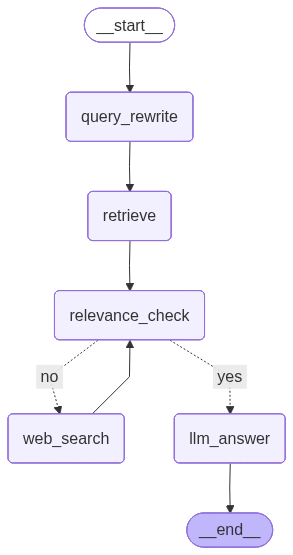

In [167]:
# 그래프 정의
workflow = StateGraph(RAGState)

# 노드 정의
workflow.add_node("query_rewrite", query_rewrite)
workflow.add_node("retrieve", retrieve_node)
workflow.add_node("relevance_check", relevance_check)
workflow.add_node("web_search", web_search)
workflow.add_node("llm_answer", llm_answer)

# 엣지 정의
workflow.add_edge(START, "query_rewrite")
workflow.add_edge("query_rewrite", "retrieve")
workflow.add_edge("retrieve", "relevance_check")
## 조건부 엣지 추가
def is_relevant(s:RAGState) -> RAGState :
  return s['relevance']
workflow.add_conditional_edges(
    "relevance_check", # 조건 분기가 시작될 노드이름
    is_relevant, # 라우터 함수
    { # path map
        "yes" : "llm_answer",
        "no" : "web_search"
        }
)
workflow.add_edge("web_search","relevance_check")
workflow.add_edge("llm_answer", END)

# 체크포인터 생성(메모리 역할)
memory = MemorySaver()
# 그래프 컴파일
app = workflow.compile(checkpointer=memory)
# 그래프 시각화
display(Image(app.get_graph().draw_mermaid_png()))

In [168]:
query = "전남 광주 맛집 알려줘"
input = RAGState(question=query)

# 그래프 실행
for result in app.stream(input=input, config=config) :
  print(result)


  === [Query rewrite] :
    - 기존 : 전남 광주 맛집 알려줘
    - 변경 : "전남 광주에서 추천할 만한 맛집은 어디인가요?"
 
{'query_rewrite': {'question': '"전남 광주에서 추천할 만한 맛집은 어디인가요?"'}}
{'retrieve': {'context': '경기도 성남시 분당구 대왕판교로 712번길 22 글로벌 R&D 연구동(B) 4층22, Daewangpangyo-ro 712beon-gil, Bundang-gu, Seongnam-si, Gyeonggi-do, Republic of Korea, 13488\n홈페이지 : https://spri.kr/보고서와 관련된 문의는 AI정책연구실(hs.lee@spri.kr, 031-739-7333)로 연락주시기 바랍니다.\n\n2024년 11월호'}}
=========[RELEVANCE CHECK] : no
{'relevance_check': {'relevance': 'no'}}
{'web_search': {'context': "광주 음식점 · 1. 뼈칼집. 5.0. (33건의 리뷰). 아시아 요리, 한국. 영업 중 · 2. 황솔촌. 4.3. (67건의 리뷰) · 3. 나정상회. 5.0. (1건의 리뷰) · 4. 르시엘블루. 4.3. (24\n\n광주 가장 사랑받는 인기 맛집 TOP 10 · 1. 맥문동 · 2. 명화식육식당 · 3. 쌍교숯불갈비 송정점 · 4. 영미오리탕 · 5. 상무초밥 · 6. 김강심칼국수 · 7. 나정\n\n0:00 돈가스 ‣ 오코25 전라남도 화순군 동면 응봉로 335 061-371-7999 *체험농장 사전예약 전화 및 카카오톡 플러스친구 '오코농장' 4:07 양념돼지"}}
=========[RELEVANCE CHECK] : yes
{'relevance_check': {'relevance': 'yes'}}
{'llm_answer': {'answer': '전남 광주에서 추천할 만한 맛집으로는 다음과 같은 곳들이 있습니다:\n\n1. **맥

- web search 검색 결과에 대한 검증성이 no인 경우는 deep_search 같은 속성을 state에 추가하고 기존 web api 이외에 다른 api가 호출되도록 웹 서치 노드를 수정하면 된다.

deep seek api 추가해볼것